**Import libraries and functions**

In [82]:
#Import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

# --- Display coefficients ---
def display_coefficients(model_pipe, model_name):
    regressor = model_pipe['regressor']
    if hasattr(regressor, 'coef_'):
        coefficients = regressor.coef_
    else:
        print(f"Impossible d'obtenir les coefficients pour {model_name}.")
        return
    feature_names = model_pipe['preprocessor'].get_feature_names_out()
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    coef_df['Absolute_Coefficient'] = coef_df['Coefficient'].abs()
    coef_df = coef_df.sort_values(by='Absolute_Coefficient', ascending=False)
    print(f"\n--- Poids des Features pour : {model_name} ---")
    print(coef_df.drop(columns='Absolute_Coefficient').to_string(index=False))

**Import and check data**

In [84]:
#Data import
df_gym_tracking=pd.read_csv("gym_members_exercise_tracking.csv", sep= ",", encoding="latin")

In [85]:
#Data check - Columns type
df_gym_tracking.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [86]:
#Check duplicates
df_gym_tracking.duplicated().sum()

0

In [87]:
#Check if na
df_gym_tracking.isna().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [88]:
df_gym_tracking.shape

(973, 15)

In [89]:
df_gym_tracking.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


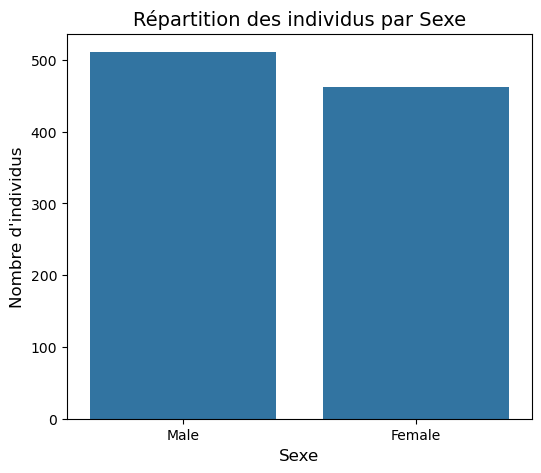

In [90]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df_gym_tracking, x="Gender", ax=ax)

ax.set_title("Répartition des individus par Sexe", fontsize=14)
ax.set_xlabel("Sexe", fontsize=12)
ax.set_ylabel("Nombre d'individus", fontsize=12)

plt.show()

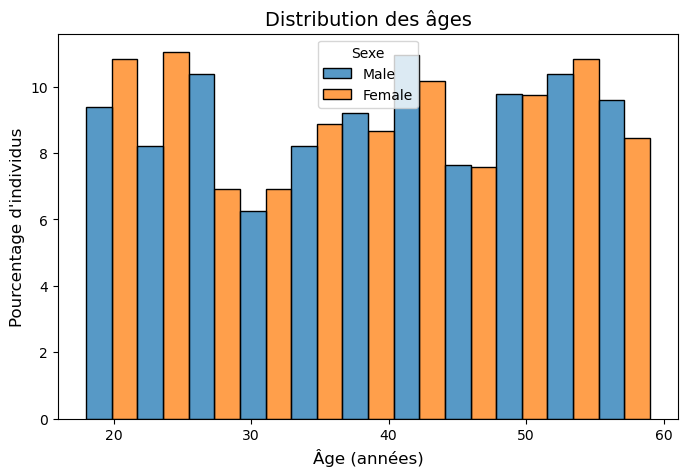

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_gym_tracking, x="Age", hue="Gender", stat='percent', multiple='dodge', common_norm=False, ax=ax)
ax.set_title("Distribution des âges", fontsize=14)
ax.set_xlabel("Âge (années)", fontsize=12)
ax.set_ylabel("Pourcentage d'individus", fontsize=12)
ax.get_legend().set_title("Sexe")
plt.show()

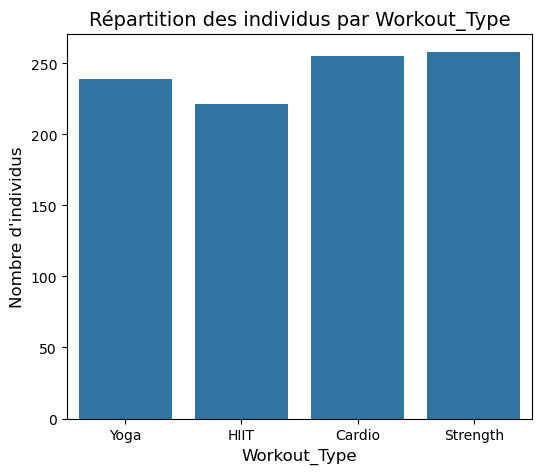

In [92]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df_gym_tracking, x="Workout_Type", ax=ax)

ax.set_title("Répartition des individus par Workout_Type", fontsize=14)
ax.set_xlabel("Workout_Type", fontsize=12)
ax.set_ylabel("Nombre d'individus", fontsize=12)

plt.show()

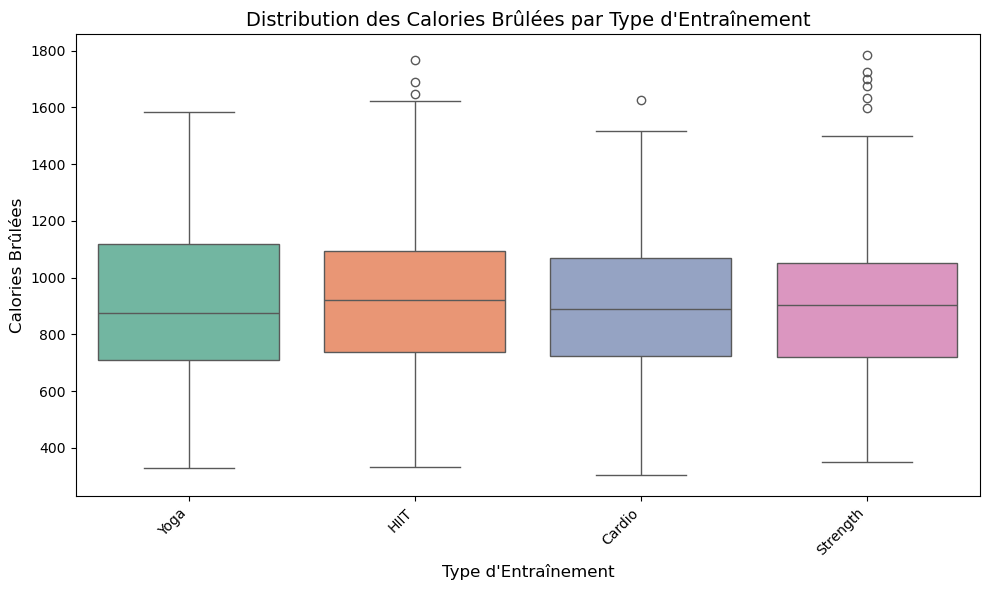

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_gym_tracking, 
    x="Workout_Type",          
    y="Calories_Burned",
    hue="Workout_Type",       
    palette="Set2",
    legend=False,            
    ax=ax            
)

ax.set_title("Distribution des Calories Brûlées par Type d'Entraînement", fontsize=14)
ax.set_xlabel("Type d'Entraînement", fontsize=12)
ax.set_ylabel("Calories Brûlées", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

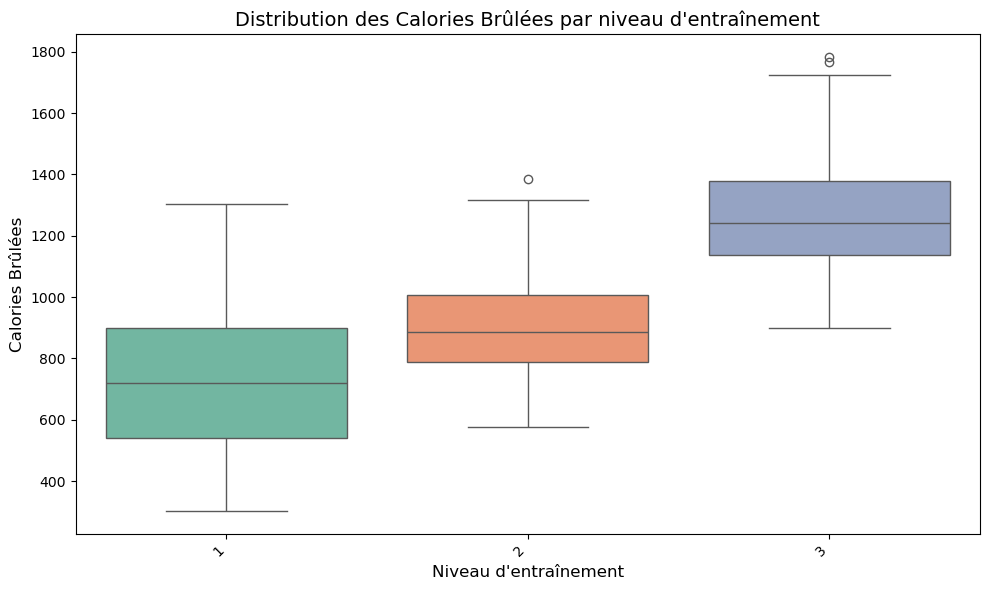

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_gym_tracking, 
    x="Experience_Level",          
    y="Calories_Burned",
    hue="Experience_Level",       
    palette="Set2",
    legend=False,            
    ax=ax            
)

ax.set_title("Distribution des Calories Brûlées par niveau d'entraînement", fontsize=14)
ax.set_xlabel("Niveau d'entraînement", fontsize=12)
ax.set_ylabel("Calories Brûlées", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Linear Regression**

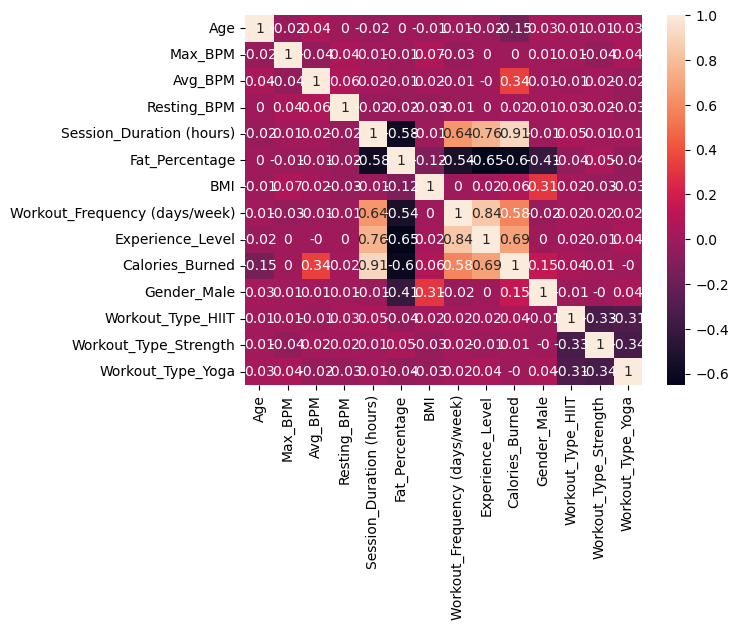

In [96]:
df_correlation_matrix = df_gym_tracking[[
    "Age", "Gender", "Max_BPM", "Avg_BPM", "Resting_BPM", "Session_Duration (hours)",
    "Fat_Percentage", "Workout_Type","BMI", "Workout_Frequency (days/week)",
    "Experience_Level", "Calories_Burned"
]]

categorical_fields = df_correlation_matrix.select_dtypes(include=["object", "category"])
df_correlation_matrix = pd.get_dummies(df_correlation_matrix, columns=categorical_fields.columns.tolist(), drop_first=True)
correlation_matrix = df_correlation_matrix.corr().round(2)
sns.heatmap(correlation_matrix, annot=True)
plt.show()

In [97]:
remarkable_values_calories = []
target_column = "Calories_Burned"

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[1]):
        correlation_value = correlation_matrix.iloc[i, j]
        col_i = correlation_matrix.columns[i]
        col_j = correlation_matrix.columns[j]
        if abs(correlation_value) >= 0.3 and (col_i == target_column or col_j == target_column):
            remarkable_values_calories.append((correlation_value, col_i, col_j))

if remarkable_values_calories:
    print(f"Correlations remarquables (valeur absolue >= 0.3) impliquant {target_column}:")
    for value, col1, col2 in remarkable_values_calories:
        print(f"  {col1} vs {col2}: {value:.2f}")
else:
    print(f"Aucune corrélation 'remarquable' (>= 0.3) n'a été trouvée avec {target_column}.")

Correlations remarquables (valeur absolue >= 0.3) impliquant Calories_Burned:
  Avg_BPM vs Calories_Burned: 0.34
  Session_Duration (hours) vs Calories_Burned: 0.91
  Fat_Percentage vs Calories_Burned: -0.60
  Workout_Frequency (days/week) vs Calories_Burned: 0.58
  Experience_Level vs Calories_Burned: 0.69


*Data preprocessing*

In [99]:
df_pipe = df_gym_tracking[[
    "Session_Duration (hours)", "Fat_Percentage", "Experience_Level",
    "Avg_BPM", "Age", "Gender", "Calories_Burned"
]].copy()

y = df_pipe['Calories_Burned']
X = df_pipe.drop('Calories_Burned', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = ["Experience_Level", "Gender"]
numerical_features = ["Session_Duration (hours)", "Fat_Percentage", "Avg_BPM", "Age"]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])



*Models*

In [101]:
models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge Regression (Alpha=10.0)", Ridge(alpha=10.0, random_state=42)),
    ("Lasso Regression (Alpha=0.1)", Lasso(alpha=0.1, random_state=42, max_iter=2000))
]

for model_name, model in models:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"--- {model_name} ---")
    print(f"R² : {r2:.4f}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    coefs = pipeline.named_steps['regressor'].coef_
    feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    coef_df = pd.DataFrame({'Feature': feature_names, 'Coef': coefs})
    print(coef_df)

--- LinearRegression ---
R² : 0.9810
MAE : 29.78
RMSE : 39.81
                         Feature        Coef
0        cat__Experience_Level_2    1.840431
1        cat__Experience_Level_3   -5.710350
2               cat__Gender_Male   83.733737
3  num__Session_Duration (hours)  240.495372
4            num__Fat_Percentage   -5.619905
5                   num__Avg_BPM   88.809877
6                       num__Age  -40.434676
--- Ridge Regression (Alpha=10.0) ---
R² : 0.9801
MAE : 30.64
RMSE : 40.77
                         Feature        Coef
0        cat__Experience_Level_2    6.847101
1        cat__Experience_Level_3    2.110502
2               cat__Gender_Male   75.780437
3  num__Session_Duration (hours)  232.761888
4            num__Fat_Percentage   -9.906140
5                   num__Avg_BPM   87.736501
6                       num__Age  -39.851564
--- Lasso Regression (Alpha=0.1) ---
R² : 0.9810
MAE : 29.73
RMSE : 39.82
                         Feature        Coef
0        cat__Experience

In [102]:
results = []
for model_name, model in models:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results.append({
        "Model": model_name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })
pd.DataFrame(results)

,Model,R2,MAE,RMSE
0,LinearRegression,0.981002,29.779219,39.810594
1,Ridge Regression (Alpha=10.0),0.980075,30.635868,40.770794
2,Lasso Regression (Alpha=0.1),0.980994,29.725240,39.819554


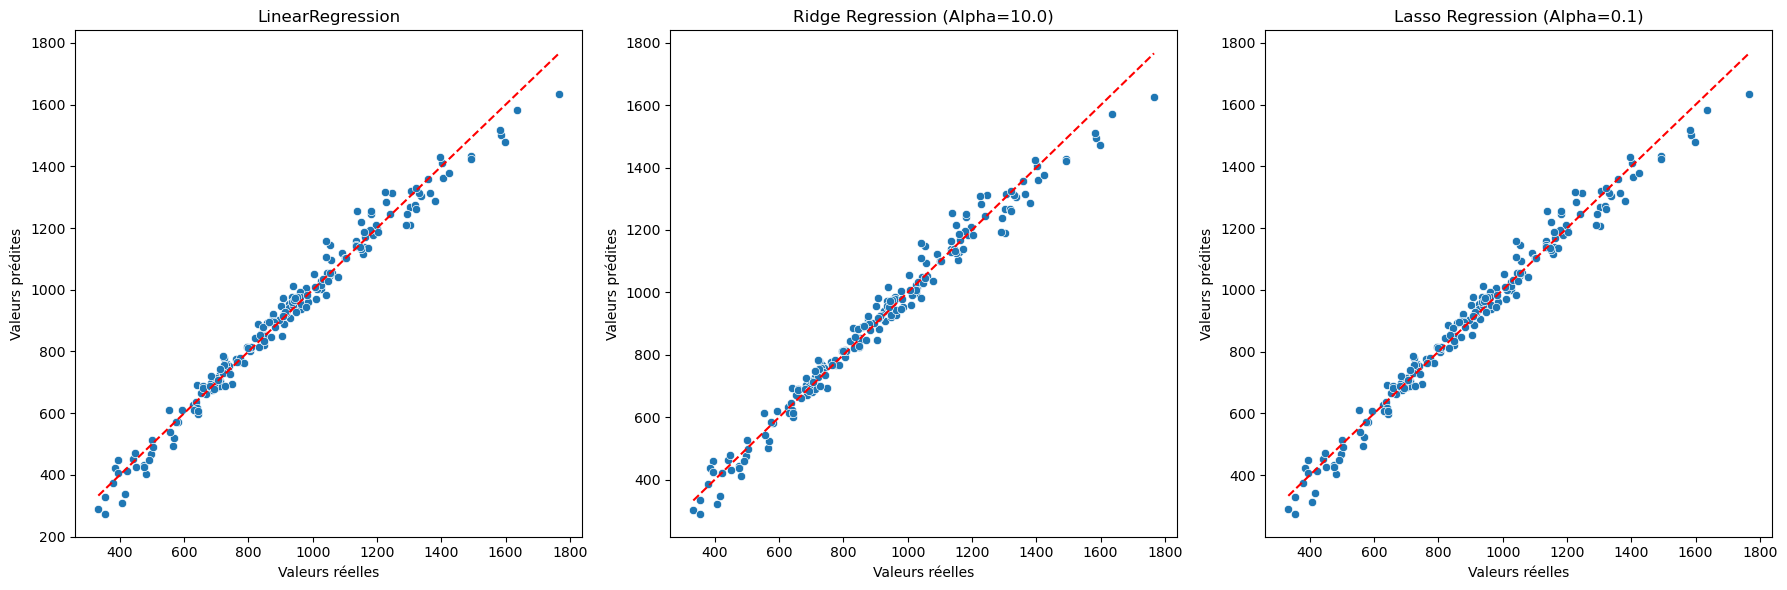

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, model) in zip(axes, models):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    sns.scatterplot(x=y_test, y=y_pred, ax=ax)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel("Valeurs réelles")
    ax.set_ylabel("Valeurs prédites")
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

In [104]:
def plot_feature_weights_ax(pipeline, model_name, ax):
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    coefs = pipeline.named_steps["regressor"].coef_

    coef_df = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefs
    }).sort_values(by="Coefficient", ascending=False)

    sns.barplot(data=coef_df, x="Coefficient", y="Feature", ax=ax)
    ax.set_title(f"Poids des features – {model_name}")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("Feature")
    return coef_df

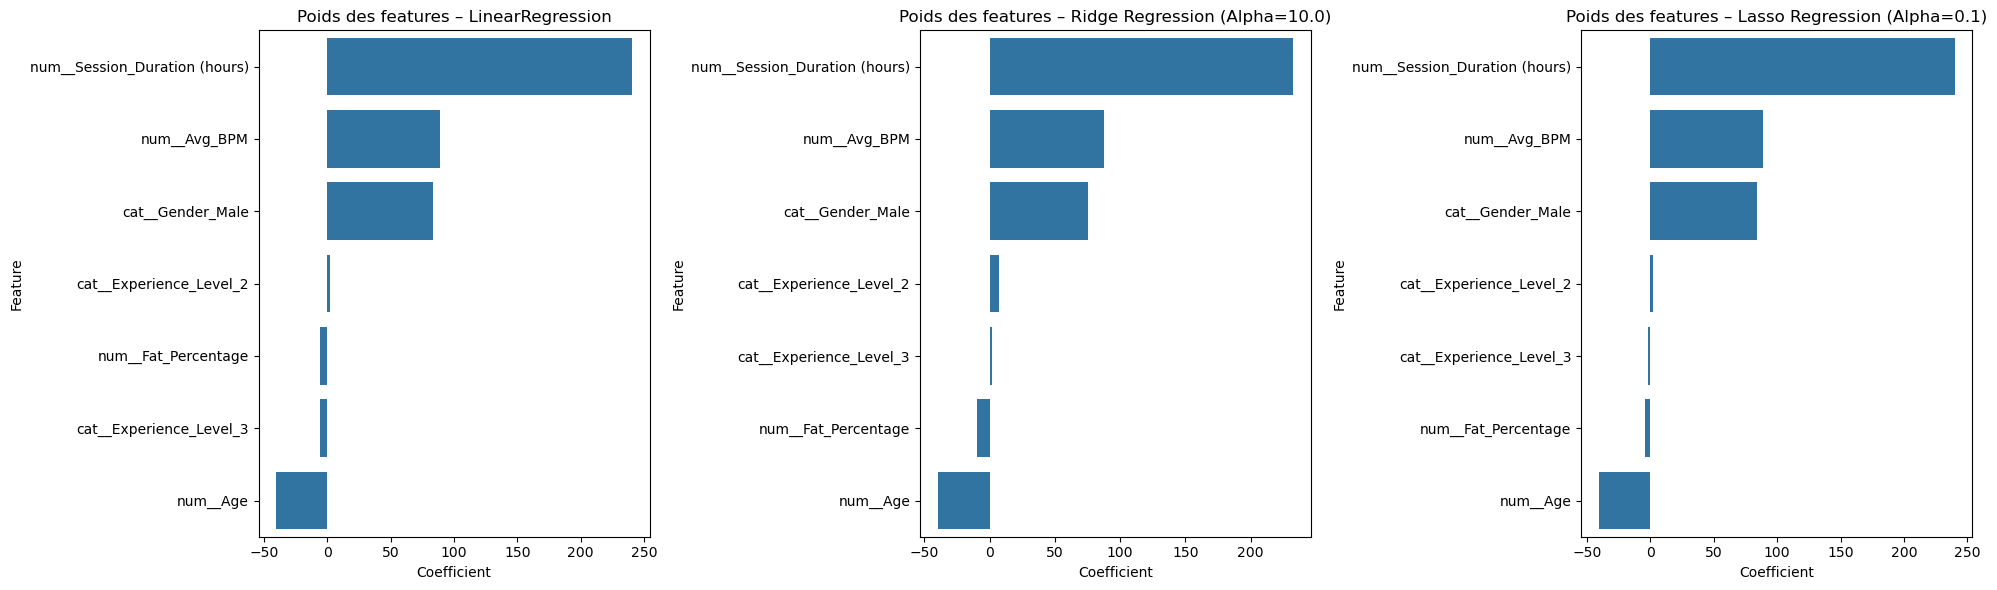

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (model_name, model) in zip(axes, models):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    plot_feature_weights_ax(pipeline, model_name, ax)

plt.tight_layout()
plt.show()
